In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

import warnings
warnings.filterwarnings('ignore')

import numpy as np
from matplotlib import pyplot as plt
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader, random_split
import torch
import sys
from functools import partial
import time
sys.path.append("..")
from src.models import MarginalDensityFlow
from src.data.reinfection import AoN, Win, PPI, InH, TwoVi, Mut, BaseReinfectionModel
from src.criticism import c2st, z_test
mps_device = torch.device("mps")
import pandas as pd

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [2]:
N = 2000
# noise = {"distr": "normal", "scale":1}
a = int(N * 0.8)
b = N - a
T = 59
# J = 100

#### Objective

Lazily attempting to rerun the marginal likelihood analysis with longer time series.

In [3]:
p_values = dict()
marginal_likelihoods = dict()

In [4]:
# jeffreys bayes factor buckets
logK = [np.log(K) for K in [1, 10**0.5, 10, 10**1.5, 100]]
evidence = ["Negligible", "Substantial", "Strong", "Very Strong", "Decisive"]
jeffreys = list(zip(evidence, logK))

In [107]:
logK

[np.float64(0.0),
 np.float64(1.151292546497023),
 np.float64(2.302585092994046),
 np.float64(3.4538776394910684),
 np.float64(4.605170185988092)]

In [5]:
def z_test(model, alpha = 0.05):
    print(f"Proportion of misspecification for model {model} at confidence level {alpha}:")
    print((p_values[model] <= alpha).mean())

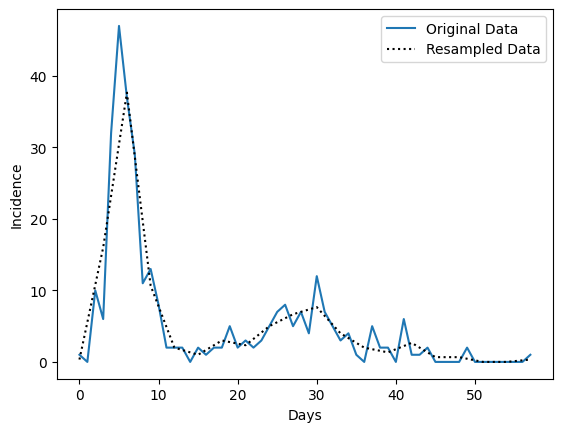

In [6]:
x_o = torch.tensor(pd.read_csv("../data/fluTDC1971.csv")["obs"].values.astype(np.float32))
k = 3
y = torch.zeros((1, 60))
y[:, :59] = x_o
y_o = y.unfold(1, k, k).sum(-1)
# y = y.unfold(1, k, k).sum(-1).numpy()[0]
plt.plot(x_o[1:], label="Original Data", color="tab:blue")
plt.plot(np.arange(0, 60, k), y_o[0] / k, label="Resampled Data", linestyle=":", color="k")
plt.ylabel("Incidence")
plt.xlabel("Days")
plt.legend()
# plt.savefig("figures/tdc_incidence_20.png")
plt.show()

In [7]:
# rescale y_o to match simulations
y_o = y_o / 284

# 0. Baseline

In [8]:
# priors
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)

In [9]:
base_dataset = BaseReinfectionModel(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, noise_scale=0.01, notebook=True,
                                   mode="criticism", load_data=False)
start = time.time()
base_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")
base_dataset.resample(3)

Simulating samples...
Time to simulate 2,000 samples: 30.4s.


In [70]:
train_data, val_data = random_split(base_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=400)
val_loader = DataLoader(val_data, batch_size=b)

In [71]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(20, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type | Params | Mode 
--------------------------------------
0 | flow | MAF  | 32.4 K | train
--------------------------------------
32.4 K    Trainable params
0         Non-trainable params
32.4 K    Total params
0.130     Total estimated model params size (MB)
32        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                          | 0/? [00:00<?, ?it/s]

Training: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

In [72]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                                               | 0/? [00:00<?, ?it/s]

tensor(0.5787, dtype=torch.float64)

In [73]:
_, log_prob = model.predict_step(y_o)
print(f"Log Marginal Likelihood: {log_prob.item():.3f} ")
p_value = (log_prob > mll_val).float().mean()
print(f"p-value: {p_value.item():.3f}")

marginal_likelihoods["Base"] = log_prob.item()
p_values["Base"] = p_value.item()

Log Marginal Likelihood: 35.806 
p-value: 0.043


# I. 2Vi
Two-virus

In [14]:
beta_1_prior = torch.distributions.Exponential(rate=0.3)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
beta_2_prior = torch.distributions.Exponential(rate=0.15)

In [94]:
twovi_dataset = TwoVi(init_I1=3, init_I2=1, init_S=277, beta_1=beta_1_prior, epsilon=epsilon_prior,
                     nu=nu_prior, rho=rho_prior, gamma=gamma_prior, beta_2=beta_2_prior, notebook=True,
                     n_sample=N, mode="criticism", noise_scale=0.01)
start = time.time()
twovi_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")
twovi_dataset.resample(k)

Simulating samples...
Time to simulate 2,000 samples: 252.0s.


In [97]:
train_data, val_data = random_split(twovi_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=400)
val_loader = DataLoader(val_data, batch_size=b)

In [98]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(20, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type | Params | Mode 
--------------------------------------
0 | flow | MAF  | 32.4 K | train
--------------------------------------
32.4 K    Trainable params
0         Non-trainable params
32.4 K    Total params
0.130     Total estimated model params size (MB)
32        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                          | 0/? [00:00<?, ?it/s]

Training: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

In [102]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                                             | 0/? [00:00<?, ?it/s]

tensor(0.5912, dtype=torch.float64)

In [104]:
_, log_prob = model.predict_step(y_o)
print(f"Log Marginal Likelihood: {log_prob.item():.3f} ")
p_value = (log_prob > mll_val).float().mean()
print(f"p-value: {p_value.item():.3f}")

marginal_likelihoods["2Vi"] = log_prob.item()
p_values["2Vi"] = p_value.item()

Log Marginal Likelihood: 38.291 
p-value: 0.237


# II. Mut

In [20]:
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
sigma_prior = torch.distributions.Uniform(low=0.1, high=0.6)
mu_prior = torch.distributions.Uniform(low=0, high=1)

In [21]:
mut_dataset = Mut(init_I=1, init_S=278, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
                                    sigma=sigma_prior, mu=mu_prior, notebook=True, noise_scale=0.01, mode="criticism")
start = time.time()
mut_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")
mut_dataset.resample(k)

Simulating samples...
Time to simulate 2,000 samples: 162.0s.


In [54]:
train_data, val_data = random_split(mut_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

In [65]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(20, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type | Params | Mode 
--------------------------------------
0 | flow | MAF  | 32.4 K | train
--------------------------------------
32.4 K    Trainable params
0         Non-trainable params
32.4 K    Total params
0.130     Total estimated model params size (MB)
32        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                          | 0/? [00:00<?, ?it/s]

Training: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

In [67]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                                               | 0/? [00:00<?, ?it/s]

tensor(0.5775, dtype=torch.float64)

In [69]:
_, log_prob = model.predict_step(y_o)
print(f"Log Marginal Likelihood: {log_prob.item():.3f} ")
p_value = (log_prob > mll_val).float().mean()
print(f"p-value: {p_value.item():.3f}")

marginal_likelihoods["Mut"] = log_prob.item()
p_values["Mut"] = p_value.item()

Log Marginal Likelihood: 41.808 
p-value: 0.335


# III. AoN
All-or-nothing

In [26]:
# priors
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
alpha_prior = torch.distributions.Uniform(low=0.1, high=0.9)

In [74]:
# aon_dataset = AoN(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
#                                     epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
#                                     alpha=alpha_prior, notebook=True, noise_scale=0.01, mode="criticism")
# start = time.time()
# aon_dataset.sample_model()
# stop = time.time()
# print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")
# aon_dataset.resample(k)
train_data, val_data = random_split(aon_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=400)
val_loader = DataLoader(val_data, batch_size=b)

In [75]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(20, 5, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type | Params | Mode 
--------------------------------------
0 | flow | MAF  | 40.5 K | train
--------------------------------------
40.5 K    Trainable params
0         Non-trainable params
40.5 K    Total params
0.162     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                          | 0/? [00:00<?, ?it/s]

Training: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

In [76]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                                               | 0/? [00:00<?, ?it/s]

tensor(0.5850, dtype=torch.float64)

In [77]:
_, log_prob = model.predict_step(y_o)
print(f"Log Marginal Likelihood: {log_prob.item():.3f} ")
p_value = (log_prob > mll_val).float().mean()
print(f"p-value: {p_value.item():.3f}")

marginal_likelihoods["AoN"] = log_prob.item()
p_values["AoN"] = p_value.item()

Log Marginal Likelihood: 39.347 
p-value: 0.245


# IV. PPI
Partial Protective Immunity

In [31]:
# priors
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
sigma_prior = torch.distributions.Uniform(low=0.1, high=0.6)

In [78]:
# ppi_dataset = PPI(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
#                                     epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
#                                     sigma=sigma_prior, notebook=True, mode="criticism", noise_scale=0.01)
# start = time.time()
# ppi_dataset.sample_model()
# stop = time.time()
# print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")
# ppi_dataset.resample(k)
train_data, val_data = random_split(ppi_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=400)
val_loader = DataLoader(val_data, batch_size=b)

In [79]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(20, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type | Params | Mode 
--------------------------------------
0 | flow | MAF  | 32.4 K | train
--------------------------------------
32.4 K    Trainable params
0         Non-trainable params
32.4 K    Total params
0.130     Total estimated model params size (MB)
32        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                          | 0/? [00:00<?, ?it/s]

Training: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

In [81]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                                               | 0/? [00:00<?, ?it/s]

tensor(0.5837, dtype=torch.float64)

In [82]:
_, log_prob = model.predict_step(y_o)
print(f"Log Marginal Likelihood: {log_prob.item():.3f} ")
p_value = (log_prob > mll_val).float().mean()
print(f"p-value: {p_value.item():.3f}")

marginal_likelihoods["PPI"] = log_prob.item()
p_values["PPI"] = p_value.item()

Log Marginal Likelihood: 38.148 
p-value: 0.360


# V. InH
In-host

In [36]:
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=12)
alpha_prior = torch.distributions.Uniform(low=0.1, high=0.9)

In [46]:
# inh_dataset = InH(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
#                                     epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
#                                     alpha=alpha_prior, notebook=True, noise_scale=0.01, mode="criticism")
# start = time.time()
# inh_dataset.sample_model()
# stop = time.time()
# print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")
# inh_dataset.resample(k)
train_data, val_data = random_split(inh_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=400)
val_loader = DataLoader(val_data, batch_size=b)

In [47]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(20, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type | Params | Mode 
--------------------------------------
0 | flow | MAF  | 32.4 K | train
--------------------------------------
32.4 K    Trainable params
0         Non-trainable params
32.4 K    Total params
0.130     Total estimated model params size (MB)
32        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                          | 0/? [00:00<?, ?it/s]

Training: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

In [48]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                                               | 0/? [00:00<?, ?it/s]

tensor(0.5762, dtype=torch.float64)

In [49]:
_, log_prob = model.predict_step(y_o)
print(f"Log Marginal Likelihood: {log_prob.item():.3f} ")
p_value = (log_prob > mll_val).float().mean()
print(f"p-value: {p_value.item():.3f}")

marginal_likelihoods["InH"] = log_prob.item()
p_values["InH"] = p_value.item()

Log Marginal Likelihood: 25.351 
p-value: 0.013


# VI. Win
Window-of-reinfection

In [41]:
# priors
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
tau_prior = torch.distributions.Exponential(rate=4)

In [83]:
# win_dataset = Win(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
#                                     epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
#                                     tau=tau_prior, notebook=True, noise_scale=0.01, mode="criticism")
# start = time.time()
# win_dataset.sample_model()
# stop = time.time()
# print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")
# win_dataset.resample(k)
train_data, val_data = random_split(win_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=400)
val_loader = DataLoader(val_data, batch_size=b)

In [84]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(20, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type | Params | Mode 
--------------------------------------
0 | flow | MAF  | 32.4 K | train
--------------------------------------
32.4 K    Trainable params
0         Non-trainable params
32.4 K    Total params
0.130     Total estimated model params size (MB)
32        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                          | 0/? [00:00<?, ?it/s]

Training: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

In [85]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                                               | 0/? [00:00<?, ?it/s]

tensor(0.5787, dtype=torch.float64)

In [86]:
_, log_prob = model.predict_step(y_o)
print(f"Log Marginal Likelihood: {log_prob.item():.3f} ")
p_value = (log_prob > mll_val).float().mean()
print(f"p-value: {p_value.item():.3f}")

marginal_likelihoods["Win"] = log_prob.item()
p_values["Win"] = p_value.item()

Log Marginal Likelihood: 41.205 
p-value: 0.442


## Evaluate (and Save) Results

In [89]:
pd.Series(marginal_likelihoods).to_csv("results/reinfection_marginal_likelihoods_d20.csv")
pd.Series(p_values).to_csv("results/reinfection_p_values_d20.csv")

We can feel confident about rejecting the Baseline model and the In-Host model.

In [93]:
s = pd.Series(p_values)
p_table = pd.DataFrame({"Model": s.index, "$p$-value": s.values, "Reject": s.values < 0.05})
print(p_table.to_latex(float_format="{:0.5f}".format, index=False))

\begin{tabular}{lrr}
\toprule
Model & $p$-value & Reject \\
\midrule
Base & 0.04250 & True \\
2Vi & 0.16000 & False \\
Mut & 0.33500 & False \\
AoN & 0.24500 & False \\
PPI & 0.36000 & False \\
InH & 0.01250 & True \\
Win & 0.44250 & False \\
\bottomrule
\end{tabular}



#### Visualizing Marginal Likelihood

In [105]:
s_lml = pd.Series(marginal_likelihoods).sort_values()
s_lml = s_lml - s_lml.min()

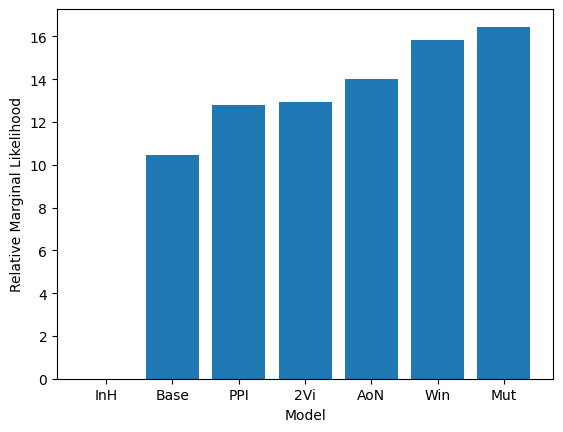

In [106]:
plt.bar(x=s_lml.index, height=s_lml.values)
plt.xlabel("Model")
plt.ylabel("Relative Marginal Likelihood")
plt.savefig("figures/relative_marginal_likelihood_d20.png")
plt.show()